In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [148]:
export_hwannier("wannier", spin=Val('n'));

In [149]:
Hwannier, cell_map = hwannier("wannier"), np.loadtxt("wannier.map.txt");

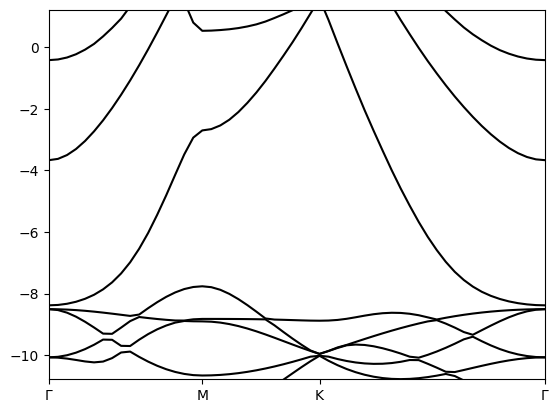

(-10.780000000000001, 1.2199999999999998)

In [150]:
plot_bands(Hwannier, cell_map, kpointsfile="../../bandstruct.kpoints", color="black")
label_plots("../../bandstruct.kpoints.in", "../../bandstruct.kpoints")
ylim(-6-4.78, 6-4.78)

In [22]:
x, y = density_of_states(Hwannier, cell_map, Val(2), mesh=20, num_blocks=1000)

([-12.876050444096384, -12.866048946403131, -12.85604744870988, -12.846045951016627, -12.836044453323375, -12.826042955630122, -12.81604145793687, -12.806039960243618, -12.796038462550365, -12.786036964857113  …  16.318321322507067, 16.32832282020032, 16.338324317893573, 16.348325815586826, 16.35832731328008, 16.36832881097333, 16.378330308666584, 16.388331806359837, 16.398333304053082, 16.408334801746335], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

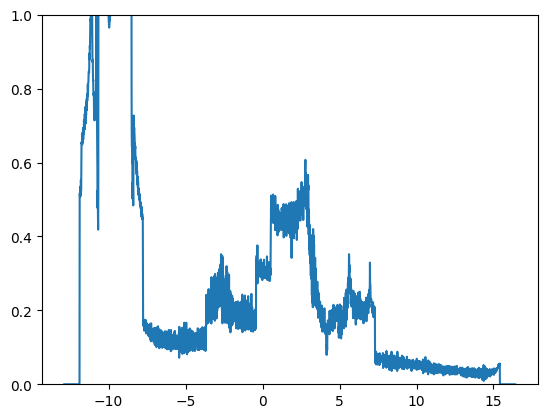

(0.0, 1.0)

In [50]:
plot(x, y)
ylim(0, 1)

In [25]:
e, n = find_chemical_potential(x, y)

([-12.866048946403131, -12.85604744870988, -12.846045951016627, -12.836044453323375, -12.826042955630122, -12.81604145793687, -12.806039960243618, -12.796038462550365, -12.786036964857113, -12.776035467163862  …  16.318321322507067, 16.32832282020032, 16.338324317893573, 16.348325815586826, 16.35832731328008, 16.36832881097333, 16.378330308666584, 16.388331806359837, 16.398333304053082, 16.408334801746335], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  9.001347923927067, 9.001347923927067, 9.001347923927067, 9.001347923927067, 9.001347923927067, 9.001347923927067, 9.001347923927067, 9.001347923927067, 9.001347923927067, 9.001347923927067])

In [55]:
JJDFTX.dosatmu(Hwannier, cell_map, -4.78, Val(2), histogram_width=1, num_blocks=300, mesh=20)

0.11650833333333334

In [35]:
force_matrix, cellph_map = phonon_force_matrix("totalE");

In [39]:
phbands = phonon_dispersion(force_matrix, cellph_map, kpointsfile="../../bandstruct.kpoints");

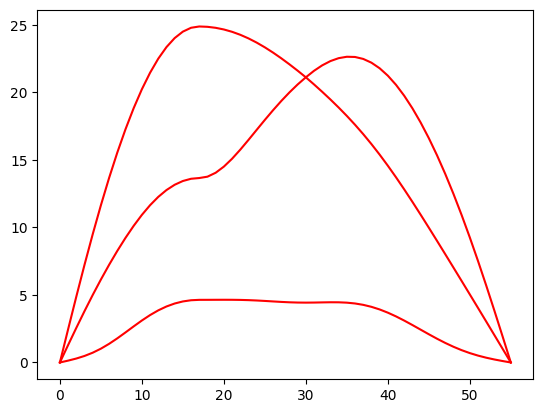

3-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f3c93748a30>
 PyObject <matplotlib.lines.Line2D object at 0x7f3c93748b20>
 PyObject <matplotlib.lines.Line2D object at 0x7f3c93748be0>

In [42]:
plot(phbands*1e3, color="red")

In [73]:
subsampling = returnfermikpoint(Hwannier, cell_map, -4.78, Val(2), mesh=20, num_blocks=1000, histogram_width=1)

(Real[0.0167927943924433 0.2996279526160577 … 0.38511845094467767 0.7488394737492428; 0.3817926818544728 0.1208155868395755 … 0.6319408609820745 0.39702900779461037; 0.0 0.0 … 0.0 0.0], 0.1133575)

In [171]:
export_heph("wannier");

In [165]:
Pwannier = export_momentum("wannier", [24, 24, 1]);

In [256]:
Heph, celleph_map = hephwannier("wannier", 9), np.loadtxt("wannier.mapeph.txt");

In [174]:
τ(Hwannier, cell_map, Pwannier, force_matrix, cellph_map, Hephwannier, celleph_map, collect(0.01:0.01:1), -4.78, supplydos=0.11, mesh=20, num_blocks=200, histogram_width=1, supplysampling=subsampling)

DOS at Fermi Energy is: 0.11
Sampling from 45343kpoints
Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Blo

100-element Vector{Float64}:
 94.75357467598903
 90.210700817969
 86.00523813108083
 82.15743724021011
 78.67274977205328
 75.54414774606423
 72.75500198781322
 70.28204739472994
 68.09808980400685
 66.17425443865048
 64.48170253721621
 62.99283341602544
 61.682042007384005
  ⋮
 47.825001172801024
 47.801087675274154
 47.77771157178378
 47.75485494879719
 47.73250068020696
 47.71063238453524
 47.689234384899116
 47.668291671531236
 47.647789866667644
 47.627715191630685
 47.60805443594702
 47.58879492835744

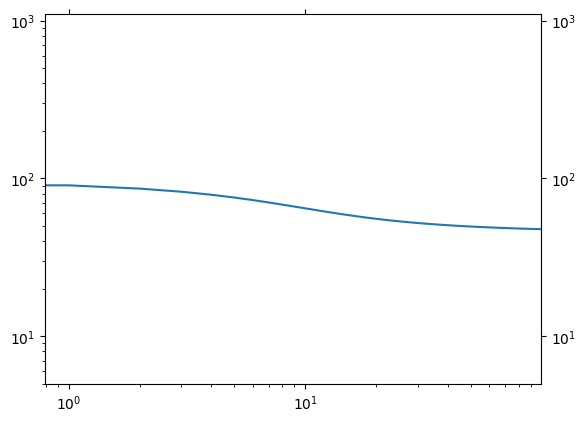

In [175]:
loglog(tau)
ylim(5, 1100)
xlim(0, 99)
tick_params(labelright=true, direction="out", tick1On=true, tick2On=true)

In [101]:
lattice_vectors=loadlattice("totalE.out")

3-element Vector{Vector{Float64}}:
 [2.764420648, 0.0, 0.0]
 [-1.382210324, 2.39406024924, 0.0]
 [0.0, 0.0, 15.87531]

In [105]:
drude_conductivity(lattice_vectors, Hwannier, cell_map, Pwannier, -4.78, Val(2), num_blocks=500, histogram_width=1, mesh=20, degeneracy=2)

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10
Block: 11
Block: 12
Block: 13
Block: 14
Block: 15
Block: 16
Block: 17
Block: 18
Block: 19
Block: 20
Block: 21
Block: 22
Block: 23
Block: 24
Block: 25
Block: 26
Block: 27
Block: 28
Block: 29
Block: 30
Block: 31
Block: 32
Block: 33
Block: 34
Block: 35
Block: 36
Block: 37
Block: 38
Block: 39
Block: 40
Block: 41
Block: 42
Block: 43
Block: 44
Block: 45
Block: 46
Block: 47
Block: 48
Block: 49
Block: 50
Block: 51
Block: 52
Block: 53
Block: 54
Block: 55
Block: 56
Block: 57
Block: 58
Block: 59
Block: 60
Block: 61
Block: 62
Block: 63
Block: 64
Block: 65
Block: 66
Block: 67
Block: 68
Block: 69
Block: 70
Block: 71
Block: 72
Block: 73
Block: 74
Block: 75
Block: 76
Block: 77
Block: 78
Block: 79
Block: 80
Block: 81
Block: 82
Block: 83
Block: 84
Block: 85
Block: 86
Block: 87
Block: 88
Block: 89
Block: 90
Block: 91
Block: 92
Block: 93
Block: 94
Block: 95
Block: 96
Block: 97
Block: 98
Block: 99
Block: 100
Block: 1

3×3 Matrix{Float64}:
  5.73283     -0.00874     -4.32546e-9
 -0.00874      5.82811      4.41346e-9
 -4.32546e-9   4.41346e-9   2.20374e-15

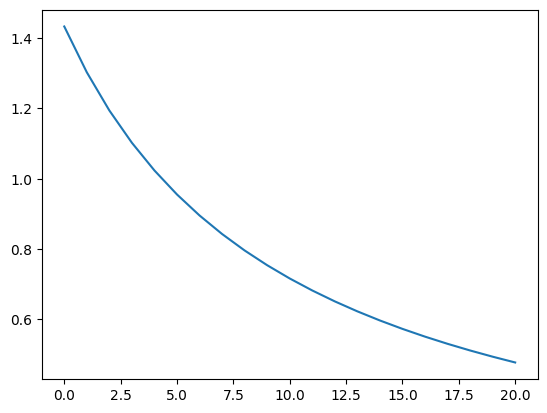

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f3c92983550>

In [109]:
plot(5.73283/4 ./ collect(1:0.1:3))

In [232]:
meshing=5

5

In [234]:
ks = vcat(rand(D, meshing^D), zeros(3-D, meshing^D))
kprimes = vcat(rand(D, meshing^D), zeros(3-D, meshing^D))

Eks, _ = wannier_bands(Hwannier, cell_map, ks)
Ekprimes, _ = wannier_bands(Hwannier, cell_map, kprimes)

omegaphsquareds, _  = JJDFTX.diagonalize_phonon(force_matrix, cellph_map, ks, kprimes)
omegaphs = sqrt.(abs.(omegaphsquareds))
omegaphs *= 1/eV;
nmodes = size(omegaphs)[end]
numbands = size(Eks)[2];
Eks = np.reshape(Eks, (meshing^D, 1, -1, 1, 1))
Ekprimes = np.reshape(Ekprimes, (1, meshing^D, 1, -1, 1));


In [236]:
Eks = np.repeat(np.repeat(np.repeat(Eks, meshing^D, axis=1), numbands, axis=3), nmodes, axis=4)
Ekprimes = np.repeat(np.repeat(np.repeat(Ekprimes, meshing^D, axis=0), numbands, axis=2), nmodes, axis=4)


25×25×9×9×3 Array{Float64, 5}:
[:, :, 1, 1, 1] =
 -10.7659  -11.1234  -11.0411  -10.7794  …  -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794  …  -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794  …  -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -10.7659  -11.1234  -11.0411  -10.7794     -11.0861  -11.2765  -11.6409
 -

In [252]:
first_order_damping(lattice_vectors, Hwannier, cell_map, force_matrix, cellph_map, Hephwannier, celleph_map, [2/3, -1/3, 0], -4.8, Val(2), mesh=10, num_blocks=10)

Block: 1
Block: 2
Block: 3
Block: 4
Block: 5
Block: 6
Block: 7
Block: 8
Block: 9
Block: 10


1000-element Vector{Float64}:
 29.467999999999996
 29.376
 29.151000000000003
 28.571000000000005
 28.585
 28.473000000000003
 28.36
 28.027
 27.750999999999998
 27.357999999999997
 27.274
 27.224999999999998
 27.087
  ⋮
  6.17
  6.064
  6.058000000000001
  6.0550000000000015
  6.114000000000001
  6.271999999999999
  6.3870000000000005
  6.264
  6.332
  6.229000000000001
  6.094
  6.107000000000001

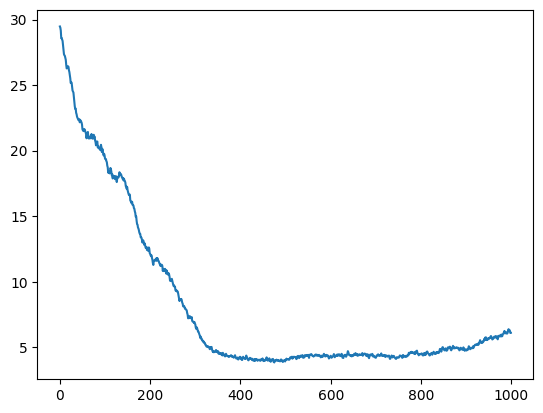

1-element Vector{PyObject}:
 PyObject <matplotlib.lines.Line2D object at 0x7f3c932b5a00>

In [253]:
plot(ans)

In [283]:
ks = rand(3, 10)
kprimes = rand(3, 10)
#ks = rand(3)
#kprimes = rand(3)
eph = eph_matrix_elements(Heph, celleph_map, force_matrix, cellph_map, Hwannier, cell_map, ks, kprimes)

10×10×3×9×9 Array{ComplexF64, 5}:
[:, :, 1, 1, 1] =
 -1.20348e-8-2.39606e-8im  …  -1.24089e-8-2.92806e-8im
 -7.89459e-9+1.33691e-8im      3.31323e-9+7.72113e-9im
 -7.79664e-9-1.50191e-8im     -3.47139e-9+2.58128e-8im
 -1.13571e-8-2.78148e-8im     -2.19317e-8-4.47834e-8im
 -1.31436e-8-4.38824e-9im      3.50681e-8-3.24939e-8im
  -3.0734e-9+9.43613e-9im  …   1.93159e-9+1.34084e-8im
 -3.68484e-8-1.924e-8im       -1.07568e-8+1.67971e-9im
 -1.67345e-9+4.17553e-9im      1.18484e-8+1.28162e-8im
 -1.71804e-9-3.36936e-9im      5.68122e-9-2.59896e-8im
 -1.00542e-8-3.44429e-8im     -2.00171e-8-5.06821e-8im

[:, :, 2, 1, 1] =
 -1.13098e-8-0.030241im    …   2.84357e-9+0.0312632im
 -4.19469e-9-0.00619877im     -4.12032e-9+0.028723im
  6.22504e-9+0.0713683im       1.41423e-9-0.0227108im
  6.01386e-9-0.014004im        8.19417e-9+0.0543042im
 -5.80402e-9-0.0366901im       4.37325e-9+0.00603827im
 -3.68286e-9-0.0155769im   …   3.75165e-9+0.106087im
 -1.64192e-9-0.0254906im      5.40099e-10+0.00538661im
 

In [284]:
eph2 = eph_matrix_elements(Heph, celleph_map, force_matrix, cellph_map, Hwannier, cell_map, kprimes, ks)

10×10×3×9×9 Array{ComplexF64, 5}:
[:, :, 1, 1, 1] =
  -1.20348e-8+2.39606e-8im  …   -1.00542e-8+3.44429e-8im
  -2.52687e-9-1.6196e-9im        5.09527e-9+4.55082e-9im
  -3.45913e-9+4.7349e-10im      -2.40301e-9+2.53408e-8im
  -2.12642e-9+7.81234e-9im       3.48191e-9-4.41178e-9im
  -1.19361e-8+1.06113e-8im      -1.61076e-8+3.13696e-8im
  -2.70784e-9-8.35263e-9im  …   -2.20516e-9-3.9364e-9im
   1.28901e-8+5.90413e-9im      -3.26614e-9-5.34654e-9im
 -7.56892e-10-7.67167e-9im     -6.35605e-10-2.08491e-8im
  6.85344e-10+3.40455e-9im      2.93565e-10+2.67797e-8im
  -1.24089e-8+2.92806e-8im      -2.00171e-8+5.06821e-8im

[:, :, 2, 1, 1] =
 -1.13098e-8+0.030241im     …    3.86844e-9+0.00453346im
  8.54812e-9+0.000806916im     -1.57714e-10+0.0444659im
  4.04192e-9+0.0544365im         1.74798e-8+0.0171834im
  1.30039e-8-0.0020983im        -2.94972e-9+0.0164264im
 -2.49428e-9-0.0236413im         4.70673e-9-0.0410483im
  1.41179e-9+0.012745im     …   -6.52298e-9+0.00353519im
 -3.88064e-9+0.0137844

In [282]:
permutedims(conj(eph), (1, 3, 2)) ≈ eph2

true

In [286]:
permutedims(conj(eph), (2, 1, 3, 5, 4)) ≈ eph2

true